<a href="https://colab.research.google.com/github/Sarah-0405/Cold_Spots_Bayern/blob/main/urbane_Cold_Spots_gi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

hier werden nicht die gesamten administrativen Flächen verwendet, sondern lediglich die bewohnten urbanen Gebiete (mit osmnx gefiltert)

# Vorbereitungen

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 84.5 MB/s eta 0:00:00


In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
import seaborn as sns
import pandas as pd
from shapely.ops import unary_union
import osmnx as ox

# urbane/bewohnte Flächen extrahieren und visualisieren

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 4.4 MB/s eta 0:00:00


In [ ]:
cities = [
    'Aschaffenburg, Bavaria, Germany',
    'Augsburg, Bavaria, Germany',
    'Bamberg, Bavaria, Germany',
    'Bayreuth, Bavaria, Germany',
    'Erlangen, Bavaria, Germany',
    'Fürth, Bavaria, Germany',
    'Ingolstadt, Bavaria, Germany',
    'Kempten (Allgäu), Bavaria, Germany',
    'Landshut, Bavaria, Germany',
    'Munich, Bavaria, Germany',
    'Nuremberg, Bavaria, Germany',
    'Passau, Bavaria, Germany',
    'Regensburg, Bavaria, Germany',
    'Rosenheim, Bavaria, Germany',
    'Schweinfurt, Bavaria, Germany',
    'Würzburg, Bavaria, Germany'
]

tags = {'landuse': ['residential', 'commercial', 'retail', 'mixed', "grass", "recreation_ground"],
         "highway":"*",
        "leisure": ["park", "garden"] }

extracted_urban_areas = {}

for city in cities:
    try:
        urban_area = ox.features_from_place(city, tags)
        extracted_urban_areas[city.split(',')[0].strip()] = urban_area
        print(f"Successfully extracted urban areas for {city}")
    except Exception as e:
        print(f"Could not extract urban areas for {city}: {e}")

# You can display the keys of the dictionary to see which cities were processed
print("\nCities processed:")
print(extracted_urban_areas.keys())

Successfully extracted urban areas for Aschaffenburg, Bavaria, Germany
Successfully extracted urban areas for Augsburg, Bavaria, Germany
Successfully extracted urban areas for Bamberg, Bavaria, Germany
Successfully extracted urban areas for Bayreuth, Bavaria, Germany
Successfully extracted urban areas for Erlangen, Bavaria, Germany
Successfully extracted urban areas for Fürth, Bavaria, Germany
Successfully extracted urban areas for Ingolstadt, Bavaria, Germany
Successfully extracted urban areas for Kempten (Allgäu), Bavaria, Germany
Successfully extracted urban areas for Landshut, Bavaria, Germany
Successfully extracted urban areas for Munich, Bavaria, Germany
Successfully extracted urban areas for Nuremberg, Bavaria, Germany
Successfully extracted urban areas for Passau, Bavaria, Germany
Successfully extracted urban areas for Regensburg, Bavaria, Germany
Successfully extracted urban areas for Rosenheim, Bavaria, Germany
Successfully extracted urban areas for Schweinfurt, Bavaria, Germ

## Single Polygon für jede urbane Fläche erstellen


**Reasoning**:
Iterate through the extracted_urban_areas dictionary, dissolve the geometries for each city to create a single urban polygon, and store them in a new dictionary.



In [ ]:
single_urban_polygons = {}

for city, urban_gdf in extracted_urban_areas.items():
    if urban_gdf.empty:
        print(f"No urban areas found for {city}")
        continue
    # Dissolve geometries to create a single polygon for the urban area
    single_polygon = urban_gdf.dissolve() # Dissolve all geometries in the GeoDataFrame
    single_urban_polygons[city] = single_polygon

print("\nCities with single urban polygons:")
print(single_urban_polygons.keys())


Cities with single urban polygons:
dict_keys(['Aschaffenburg', 'Augsburg', 'Bamberg', 'Bayreuth', 'Erlangen', 'Fürth', 'Ingolstadt', 'Kempten (Allgäu)', 'Landshut', 'Munich', 'Nuremberg', 'Passau', 'Regensburg', 'Rosenheim', 'Schweinfurt', 'Würzburg'])


## urbane Flächen vor OSM visualisieren

In [ ]:
for city, urban_polygon_gdf in single_urban_polygons.items():
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    urban_polygon_gdf.plot(ax=ax, color='red')
    ax.set_title(f'Urban Area of {city}')
    ctx.add_basemap(ax, crs=urban_polygon_gdf.crs.to_epsg())
    plt.show()

# Verknüpfen mit LST Daten

## Laden und clippen des LST-GeoDataFrames auf urbane Flächen

In [ ]:
geojson_path = '/content/drive/MyDrive/Cold Spots Bayern/averaged_lst_per_pixel_per_city_allyears.geojson'
gdf = gpd.read_file(geojson_path)

display(gdf.head())

,city,avg_summer_LST_Celsius,geometry
0,Aschaffenburg,25.827932,POINT (9.23257 49.93527)
1,Aschaffenburg,25.828958,POINT (9.2355 49.935)
2,Aschaffenburg,25.846390,POINT (9.2355 49.93527)
3,Aschaffenburg,25.713771,POINT (9.23591 49.935)
4,Aschaffenburg,25.751711,POINT (9.23591 49.93527)


In [ ]:
lst_urban_areas = {}

for city, urban_polygon_gdf in single_urban_polygons.items():
    # Ensure both GeoDataFrames have the same CRS before performing the spatial join
    if gdf.crs != urban_polygon_gdf.crs:
        gdf = gdf.to_crs(urban_polygon_gdf.crs)
        print(f"Converted gdf CRS to {urban_polygon_gdf.crs} for spatial join with {city}")

    # Perform a spatial join to keep only LST data within the urban polygon
    # 'within' keeps points that are within the urban polygon
    lst_clipped = gpd.sjoin(gdf, urban_polygon_gdf, how="inner", predicate="within")

    # Remove the 'index_right' column which is added by the spatial join
    lst_clipped = lst_clipped.drop(columns=['index_right'])

    lst_urban_areas[city] = lst_clipped
    print(f"Spatially joined LST data with urban area for {city}. Resulting GeoDataFrame has {len(lst_clipped)} data points.")

Spatially joined LST data with urban area for Aschaffenburg. Resulting GeoDataFrame has 17700 data points.
Spatially joined LST data with urban area for Augsburg. Resulting GeoDataFrame has 45589 data points.
Spatially joined LST data with urban area for Bamberg. Resulting GeoDataFrame has 31246 data points.
Spatially joined LST data with urban area for Bayreuth. Resulting GeoDataFrame has 39974 data points.
Spatially joined LST data with urban area for Erlangen. Resulting GeoDataFrame has 33711 data points.
Spatially joined LST data with urban area for Fürth. Resulting GeoDataFrame has 22920 data points.
Spatially joined LST data with urban area for Ingolstadt. Resulting GeoDataFrame has 34354 data points.
Spatially joined LST data with urban area for Kempten (Allgäu). Resulting GeoDataFrame has 14696 data points.
Spatially joined LST data with urban area for Landshut. Resulting GeoDataFrame has 41049 data points.
Spatially joined LST data with urban area for Munich. Resulting GeoData

## Visualisieren der LST der urbanen Flächen/Zentren

In [ ]:
for city, lst_gdf in lst_urban_areas.items():
    if lst_gdf.empty:
        print(f"No LST data found for the urban area of {city}. Skipping visualization.")
        continue

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Plot the LST data points with a color gradient based on 'avg_summer_LST_Celsius'
    lst_gdf.plot(column='avg_summer_LST_Celsius', ax=ax, legend=True,
                 cmap='RdYlGn_r',  # Red-Yellow-Green colormap, reversed to put red on hot side
                 markersize=5,
                 legend_kwds={'label': "Average Summer LST (°C)",
                              'orientation': "horizontal"})

    ax.set_title(f'Average Summer LST in Urban Area of {city}')
    ax.set_axis_off() # Turn off axes for a cleaner map

    # Add a basemap for context
    try:
        ctx.add_basemap(ax, crs=lst_gdf.crs.to_epsg(), source=ctx.providers.OpenStreetMap.Mapnik)
    except Exception as e:
        print(f"Could not add basemap for {city}: {e}")

    plt.show()

# LST-Verteilung visualisieren

Boxplot

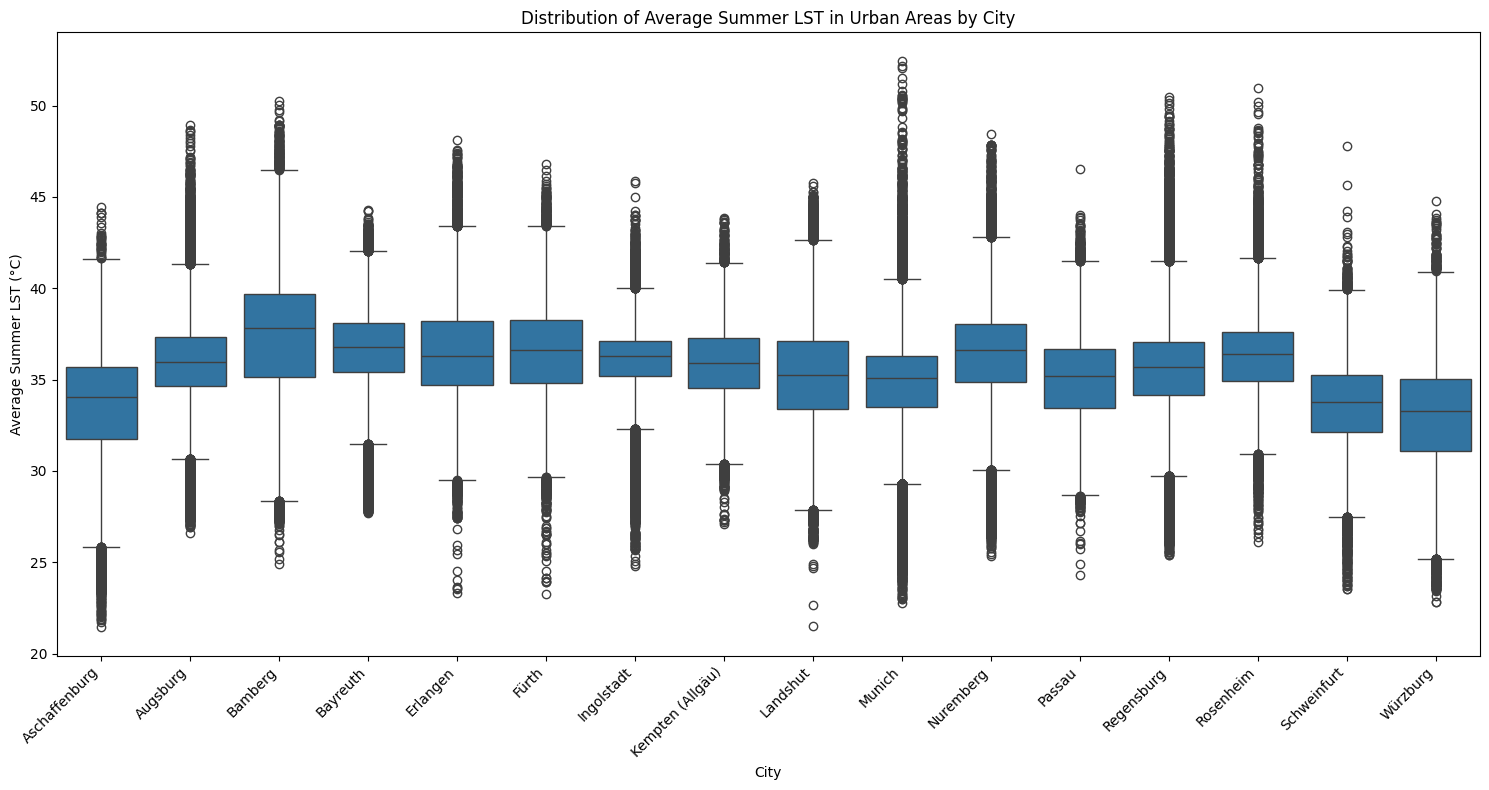

In [ ]:
# Combine LST data from all cities into a single DataFrame for easier plotting
all_lst_data = []
for city, lst_gdf in lst_urban_areas.items():
    if not lst_gdf.empty:
        # Create a temporary DataFrame with LST and city name
        temp_df = pd.DataFrame({
            'City': city,
            'Average Summer LST (°C)': lst_gdf['avg_summer_LST_Celsius']
        })
        all_lst_data.append(temp_df)

if all_lst_data:
    combined_lst_df = pd.concat(all_lst_data, ignore_index=True)

    # Create the boxplot
    plt.figure(figsize=(15, 8)) # Adjust figure size as needed
    sns.boxplot(x='City', y='Average Summer LST (°C)', data=combined_lst_df)
    plt.title('Distribution of Average Summer LST in Urban Areas by City')
    plt.xticks(rotation=45, ha='right') # Rotate city names for better readability
    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("No LST data available to create boxplots.")

als Histogramme visualisieren

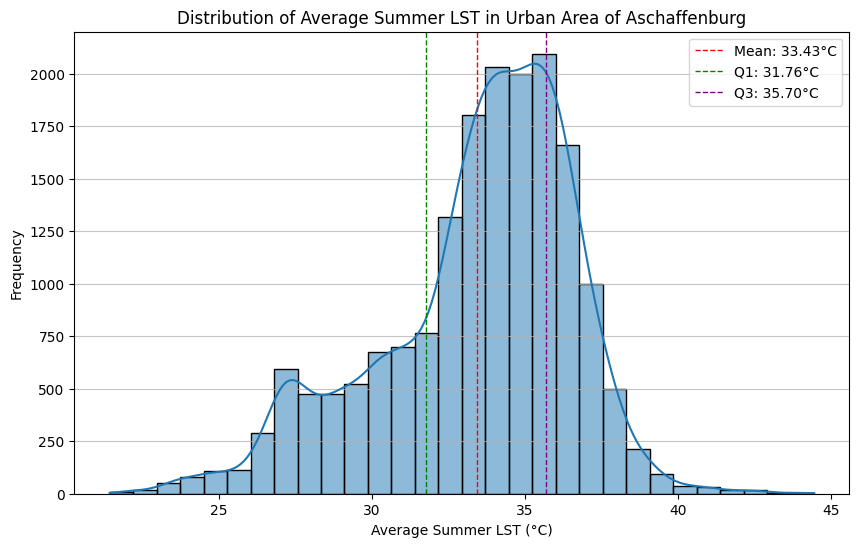

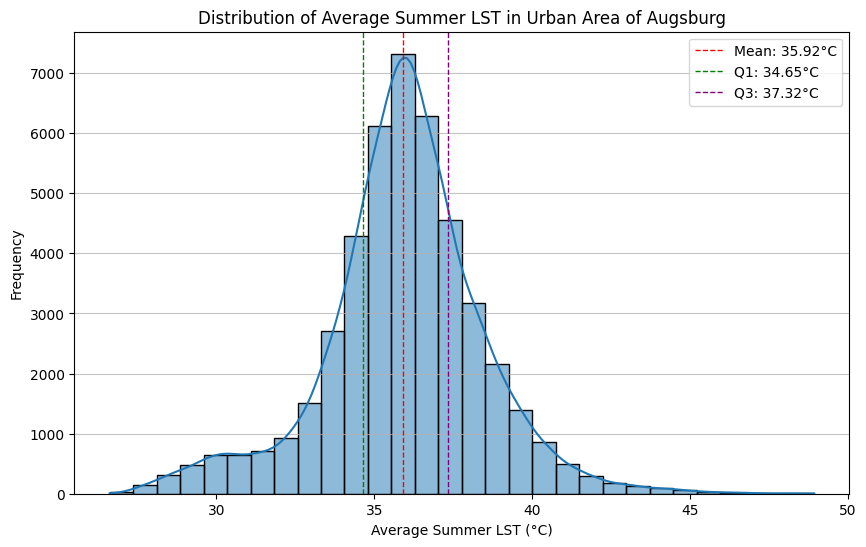

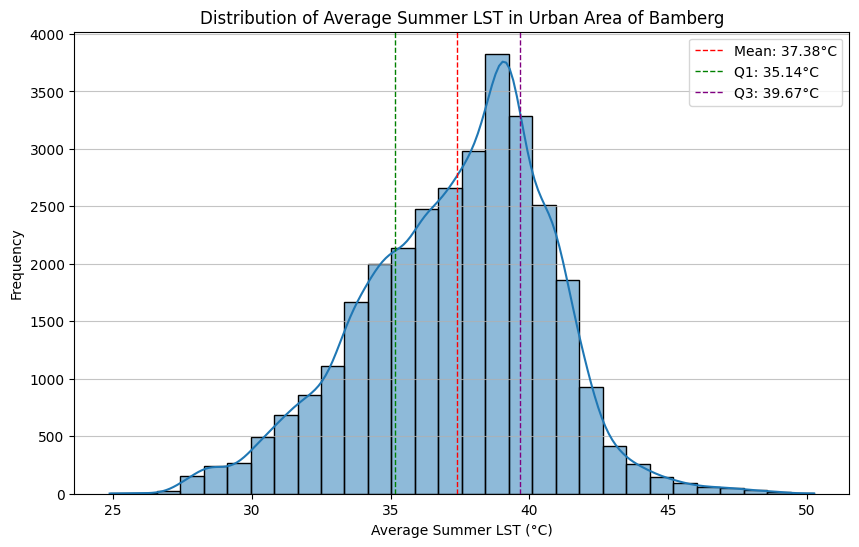

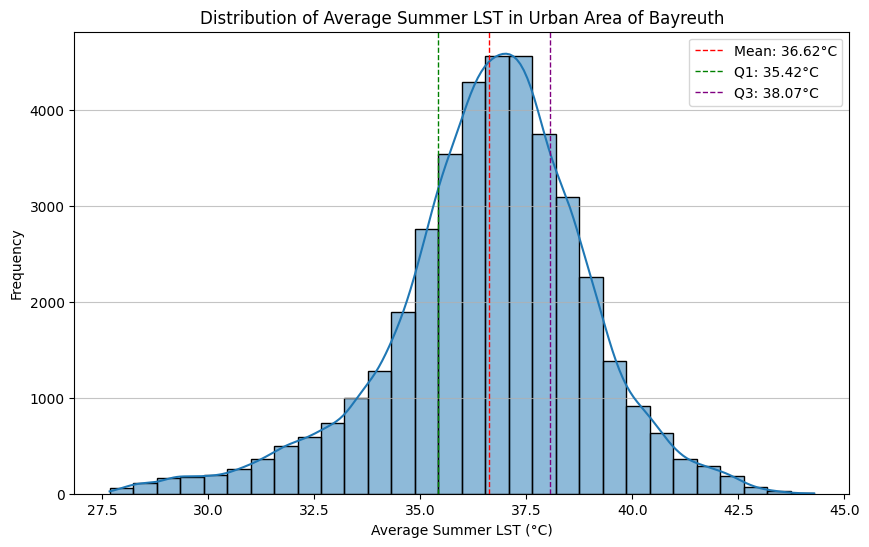

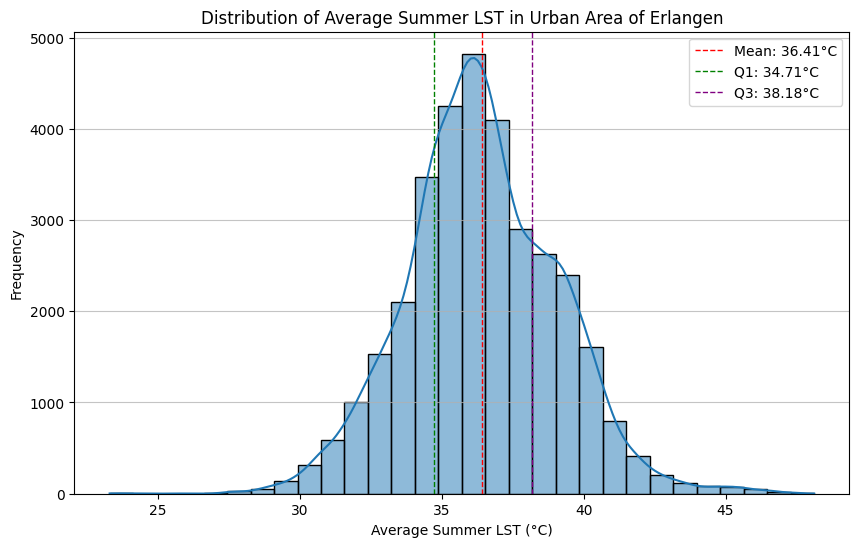

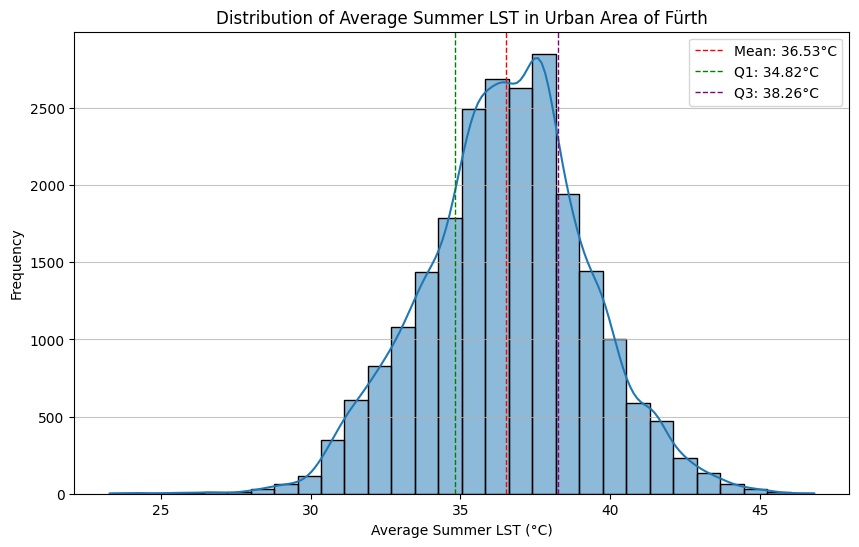

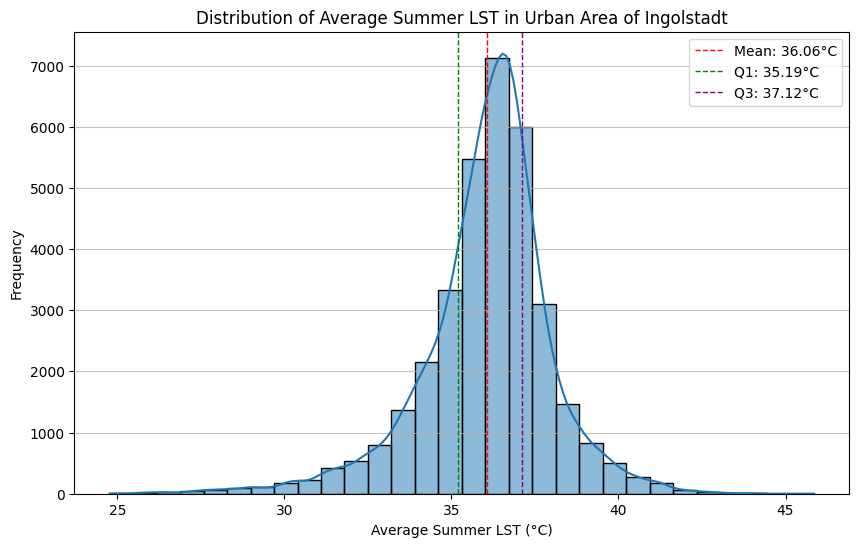

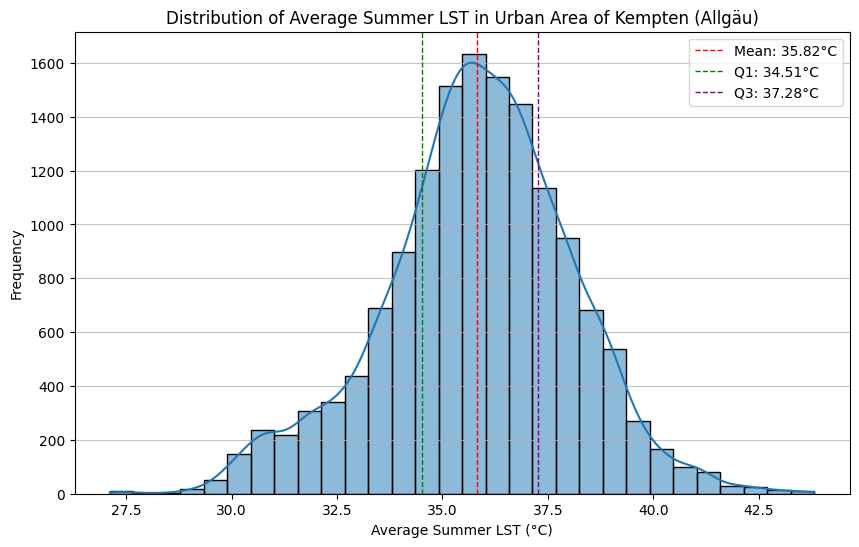

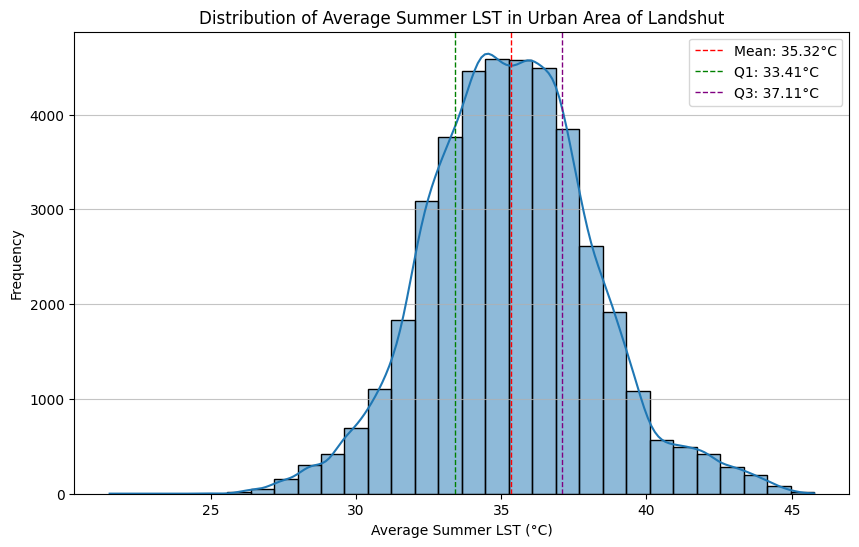

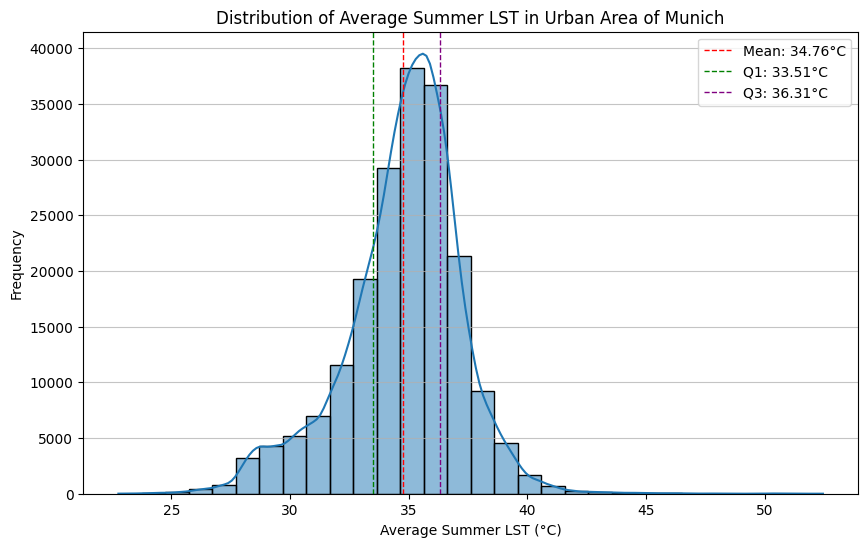

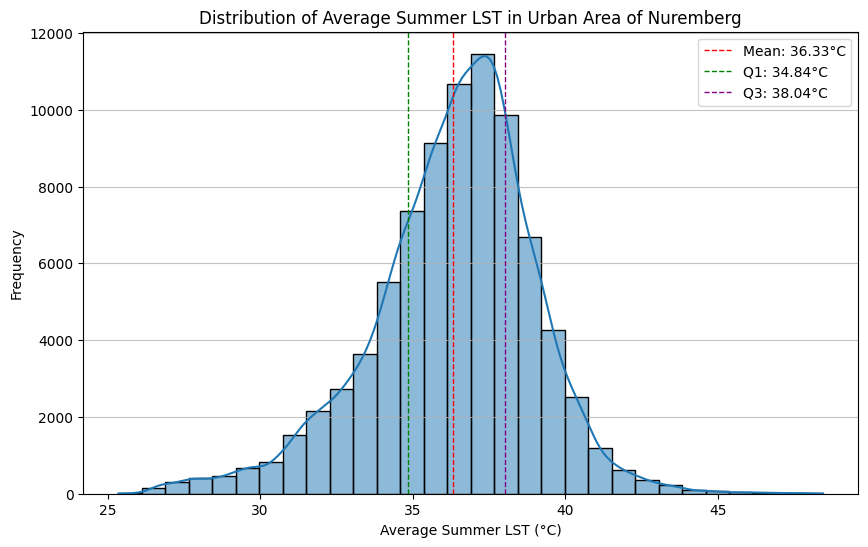

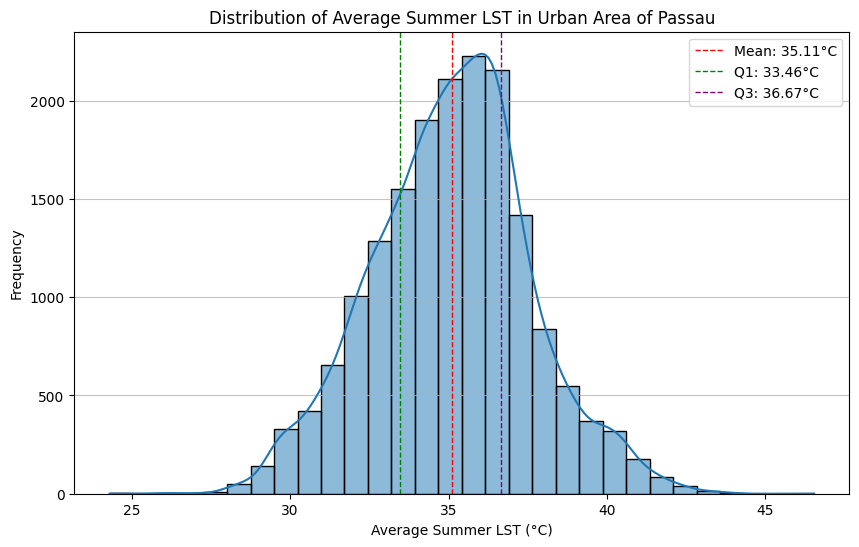

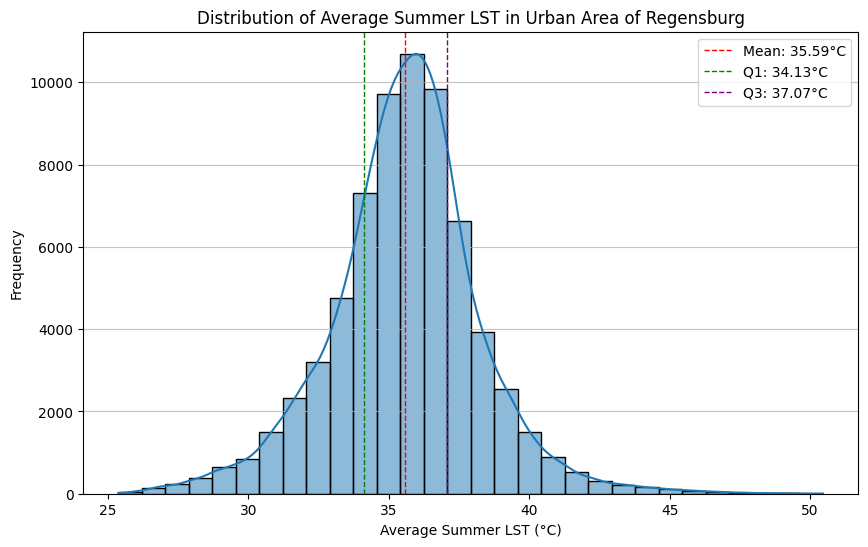

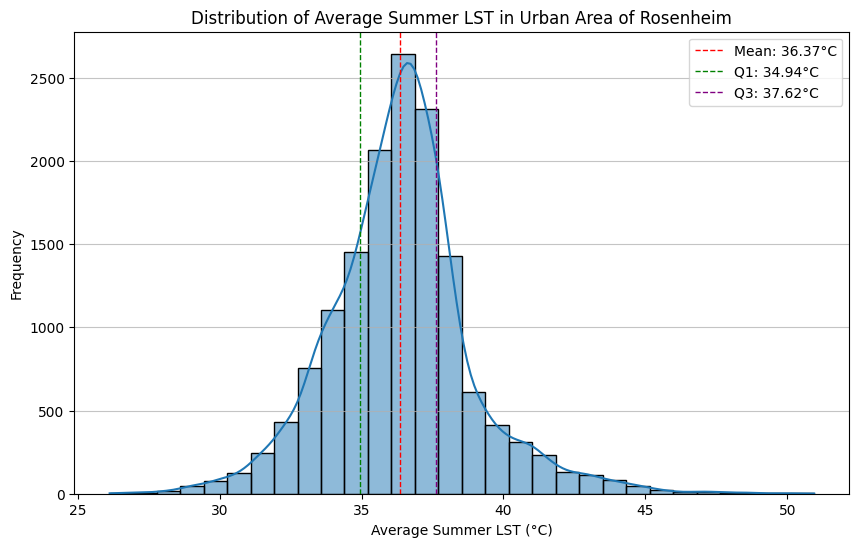

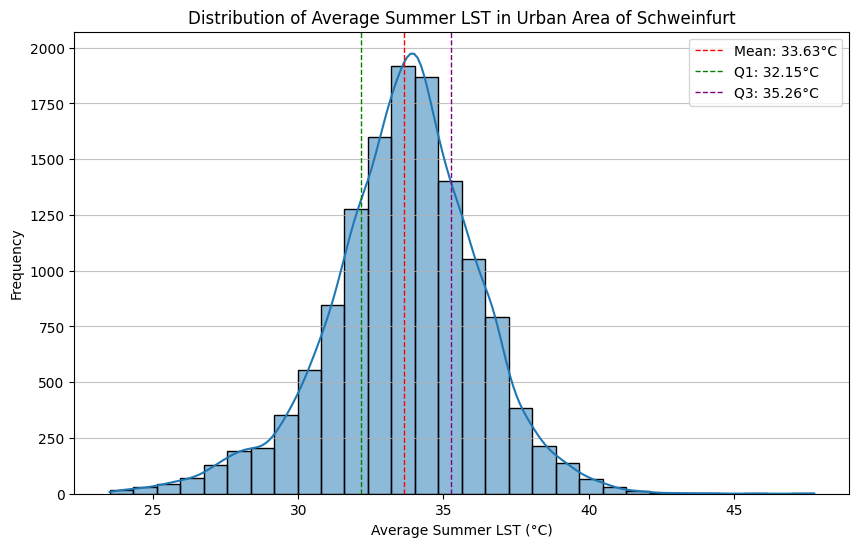

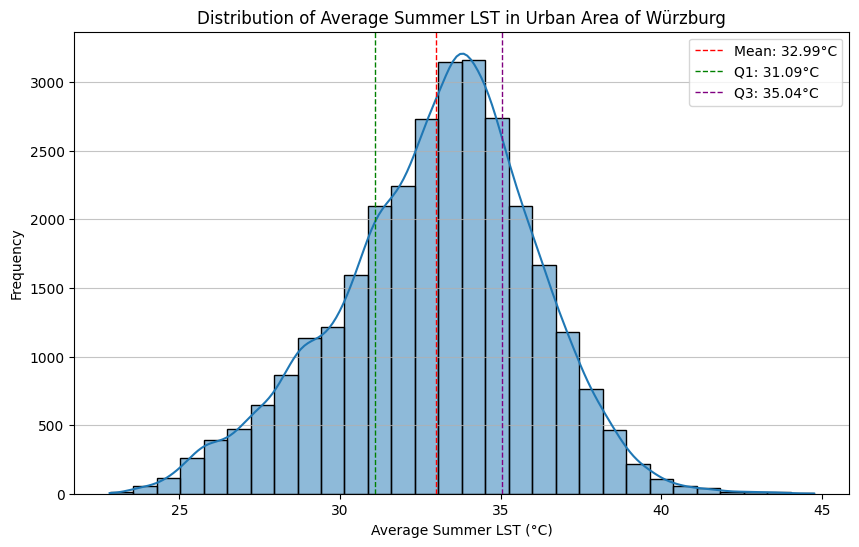

In [ ]:
for city, lst_gdf in lst_urban_areas.items():
    if lst_gdf.empty:
        print(f"No LST data found for the urban area of {city}. Skipping histogram.")
        continue

    # Extract LST values
    lst_values = lst_gdf['avg_summer_LST_Celsius']

    # Calculate mean, Q1, and Q3
    mean_lst = lst_values.mean()
    q1_lst = lst_values.quantile(0.25)
    q3_lst = lst_values.quantile(0.75)

    # Create the histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(lst_values, kde=True, bins=30) # Using seaborn for a nice histogram with KDE
    plt.title(f'Distribution of Average Summer LST in Urban Area of {city}')
    plt.xlabel('Average Summer LST (°C)')
    plt.ylabel('Frequency')

    # Add vertical lines for mean, Q1, and Q3
    plt.axvline(mean_lst, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_lst:.2f}°C')
    plt.axvline(q1_lst, color='green', linestyle='dashed', linewidth=1, label=f'Q1: {q1_lst:.2f}°C')
    plt.axvline(q3_lst, color='purple', linestyle='dashed', linewidth=1, label=f'Q3: {q3_lst:.2f}°C')

    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

# Cold Spot Algorithmus

## KNN-Matrix für jede Stadt

In [ ]:
urban_area_knn = {}

for city, lst_gdf in lst_urban_areas.items():
    if lst_gdf.empty:
        print(f"No LST data found for the urban area of {city}. Skipping KNN matrix creation.")
        urban_area_knn[city] = None  # Store None for cities with no data
        continue

    # Extract coordinates as a numpy array
    coords = np.array(list(zip(lst_gdf.geometry.x, lst_gdf.geometry.y)))

    # Create a NearestNeighbors model with k=8
    knn_model = NearestNeighbors(n_neighbors=8, algorithm='ball_tree')

    # Fit the model and find the k-nearest neighbors
    knn_model.fit(coords)
    distances, indices = knn_model.kneighbors(coords)

    # Store the indices of the k-nearest neighbors
    urban_area_knn[city] = indices

    print(f"Created KNN matrix for {city} with shape: {indices.shape}")

# You can display the keys of the dictionary to see which cities have KNN matrices
print("\nCities with KNN matrices:")
print(urban_area_knn.keys())

Created KNN matrix for Aschaffenburg with shape: (17700, 8)
Created KNN matrix for Augsburg with shape: (45589, 8)
Created KNN matrix for Bamberg with shape: (31246, 8)
Created KNN matrix for Bayreuth with shape: (39974, 8)
Created KNN matrix for Erlangen with shape: (33711, 8)
Created KNN matrix for Fürth with shape: (22920, 8)
Created KNN matrix for Ingolstadt with shape: (34354, 8)
Created KNN matrix for Kempten (Allgäu) with shape: (14696, 8)
Created KNN matrix for Landshut with shape: (41049, 8)
Created KNN matrix for Munich with shape: (194141, 8)
Created KNN matrix for Nuremberg with shape: (82978, 8)
Created KNN matrix for Passau with shape: (17681, 8)
Created KNN matrix for Regensburg with shape: (68638, 8)
Created KNN matrix for Rosenheim with shape: (14727, 8)
Created KNN matrix for Schweinfurt with shape: (13202, 8)
Created KNN matrix for Würzburg with shape: (29513, 8)

Cities with KNN matrices:
dict_keys(['Aschaffenburg', 'Augsburg', 'Bamberg', 'Bayreuth', 'Erlangen', 'Fü

In [ ]:
!pip install esda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.8/142.8 kB 5.4 MB/s eta 0:00:00


## Gi* Algorithmus

In [ ]:
import libpysal
import esda

urban_area_gi_star = {}

for city, lst_gdf in lst_urban_areas.items():
    if lst_gdf.empty or urban_area_knn[city] is None:
        print(f"Skipping Gi* analysis for {city} due to missing LST data or KNN matrix.")
        urban_area_gi_star[city] = None
        continue

    # Get the 'avg_summer_LST_Celsius' values as a numpy array
    y = lst_gdf['avg_summer_LST_Celsius'].values

    # Create a spatial weights matrix from the KNN indices
    # libpysal expects a dictionary where keys are observation indices and values are lists of neighbor indices
    knn_indices = urban_area_knn[city]
    neighbors_dict = {i: list(knn_indices[i]) for i in range(len(knn_indices))}
    w = libpysal.weights.W(neighbors_dict)
    w.transform = 'r' # Row-standardization

    # Perform the Getis-Ord Gi* analysis
    gi_star = esda.getisord.G_Local(y, w)

    # Add the Gi* statistic and p-value to the GeoDataFrame
    lst_gdf[f'{city}_gistar'] = gi_star.Gs
    lst_gdf[f'{city}_gistar_pvalue'] = gi_star.p_sim # Using simulated p-values

    urban_area_gi_star[city] = lst_gdf

    print(f"Performed Gi* analysis for {city}. Added '{city}_gistar' and '{city}_gistar_pvalue' columns.")

# You can display the keys of the dictionary to see which cities have Gi* results
print("\nCities with Gi* results:")
print(urban_area_gi_star.keys())

Performed Gi* analysis for Aschaffenburg. Added 'Aschaffenburg_gistar' and 'Aschaffenburg_gistar_pvalue' columns.
Performed Gi* analysis for Augsburg. Added 'Augsburg_gistar' and 'Augsburg_gistar_pvalue' columns.
Performed Gi* analysis for Bamberg. Added 'Bamberg_gistar' and 'Bamberg_gistar_pvalue' columns.
Performed Gi* analysis for Bayreuth. Added 'Bayreuth_gistar' and 'Bayreuth_gistar_pvalue' columns.
Performed Gi* analysis for Erlangen. Added 'Erlangen_gistar' and 'Erlangen_gistar_pvalue' columns.
Performed Gi* analysis for Fürth. Added 'Fürth_gistar' and 'Fürth_gistar_pvalue' columns.
Performed Gi* analysis for Ingolstadt. Added 'Ingolstadt_gistar' and 'Ingolstadt_gistar_pvalue' columns.
Performed Gi* analysis for Kempten (Allgäu). Added 'Kempten (Allgäu)_gistar' and 'Kempten (Allgäu)_gistar_pvalue' columns.
Performed Gi* analysis for Landshut. Added 'Landshut_gistar' and 'Landshut_gistar_pvalue' columns.
Performed Gi* analysis for Munich. Added 'Munich_gistar' and 'Munich_gistar_

In [ ]:
print(urban_area_gi_star['Aschaffenburg'].head())

               city  avg_summer_LST_Celsius                  geometry leisure  \
1270  Aschaffenburg               27.830265  POINT (9.21546 49.94232)    park   
1389  Aschaffenburg               29.212285  POINT (9.21421 49.94178)    park   
1390  Aschaffenburg               29.838352  POINT (9.21379 49.94178)    park   
1391  Aschaffenburg               30.197814  POINT (9.21379 49.94205)    park   
1392  Aschaffenburg               30.693997  POINT (9.21337 49.94206)    park   

                        name   wikidata                    wikipedia  \
1270  Saint Germain Terrasse  Q20851086  de:Schöntal (Aschaffenburg)   
1389  Saint Germain Terrasse  Q20851086  de:Schöntal (Aschaffenburg)   
1390  Saint Germain Terrasse  Q20851086  de:Schöntal (Aschaffenburg)   
1391  Saint Germain Terrasse  Q20851086  de:Schöntal (Aschaffenburg)   
1392  Saint Germain Terrasse  Q20851086  de:Schöntal (Aschaffenburg)   

                                                website landuse  \
1270  https:/

## Geodataframe nach Cold Spots filtern
Filter the `urban_area_gi_star` GeoDataFrame for each city to include only the data points where the p-value is less than or equal to 0.05 and the Gi* statistic is negative, store the results in a new dictionary called `urban_area_cold_spots`, and visualize the cold spots for each city in blue on an OpenStreetMap basemap.

In [ ]:
urban_area_cold_spots = {}

for city, lst_gdf in urban_area_gi_star.items():
    if lst_gdf is not None:
        # Filter for cold spots: Gi* statistic < 0 and p-value <= 0.05
        cold_spots = lst_gdf[(lst_gdf[f'{city}_gistar'] < 0) & (lst_gdf[f'{city}_gistar_pvalue'] <= 0.05)]
        urban_area_cold_spots[city] = cold_spots
        print(f"Found {len(cold_spots)} cold spots in {city}.")
    else:
        urban_area_cold_spots[city] = None
        print(f"No LST data or Gi* results for {city}. Skipping cold spot identification.")

print("\nCities with identified cold spots:")
print(urban_area_cold_spots.keys())

Found 0 cold spots in Aschaffenburg.
Found 0 cold spots in Augsburg.
Found 0 cold spots in Bamberg.
Found 0 cold spots in Bayreuth.
Found 0 cold spots in Erlangen.
Found 0 cold spots in Fürth.
Found 0 cold spots in Ingolstadt.
Found 0 cold spots in Kempten (Allgäu).
Found 0 cold spots in Landshut.
Found 0 cold spots in Munich.
Found 0 cold spots in Nuremberg.
Found 0 cold spots in Passau.
Found 0 cold spots in Regensburg.
Found 0 cold spots in Rosenheim.
Found 0 cold spots in Schweinfurt.
Found 0 cold spots in Würzburg.

Cities with identified cold spots:
dict_keys(['Aschaffenburg', 'Augsburg', 'Bamberg', 'Bayreuth', 'Erlangen', 'Fürth', 'Ingolstadt', 'Kempten (Allgäu)', 'Landshut', 'Munich', 'Nuremberg', 'Passau', 'Regensburg', 'Rosenheim', 'Schweinfurt', 'Würzburg'])


**es wurden keine signifikanten Cold Spots gefunden** => die kalten Pixel sind nicht kalt genug, um signifikant zu sein, oder zu klein und werden in den Landsat Daten nicht erkannt